Задание 2:

Выберите 1 из 2-ух временных рядов из задания 1 и сделайте прогноз на ближайший месяц-квартал-полугодие и год. Модель выбирать исходя из ваших предположений и умозаключений. Необходимо обосновать почему была выбрана та или иная модель и на каких основаниях, в чем она лучше и почему она подходит. Оценить качество прогноза согласно выбранной метрике, проверить качество на отложенной выборке путем применения TimeSeriesSplit. Сформировать отчет с выводами и визуализациями в jupyter notebook'e.


Исходным датасетом выбран ряд для **ASML**.

### 1. Сетка и данные

Недельная сетка — компромисс между дневными котировками, где много случайного шума и риск переобучения feature-based модели, и более редкой агрегацией, где теряется слишком много наблюдений. После перехода к неделям ряд становится устойчивее, а горизонты из задания (месяц, квартал, полгода, год) естественно выражаются в **4 / 13 / 26 / 52** шагах вперёд от последней даты ряда. При этом сохраняется достаточно истории с 2017 года для `TimeSeriesSplit` и hold-out 10%, а ошибки на hold-out можно интерпретировать и в log-доходностях, и в долларах через восстановленный недельный `Close`.


### 2. Модель

Для недельной цены ASML уместна **feature-based** регрессия (Ridge, Lasso, упрощённый CatBoost): в признаках явно заданы недавняя динамика, волатильность и диапазон недели, без жёсткого тренда и фиксированной сезонности. Предсказываем **доходность**, а не уровень цены — так ряд ведёт себя стабильнее, а прогноз на месяц–год собирается пошагово, что соответствует тому, как на практике накапливается неопределённость на длинном горизонте. Сравнение моделей и выбор лучшей делаем в `TimeSeriesSplit` по рекурсивному прогнозу на **4 / 13 / 26 / 52** неделях; регуляризация, ограниченный CatBoost и бейзлайн **Naive** не дают «запомнить» шум среди множества лагов.

Почему не другие подходы:

- **Holt–Winters** рассчитан на устойчивый тренд и повторяющуюся сезонность с фиксированным периодом; у недельной цены ASML сезонность слабая, а на длинном горизонте модель часто слишком уверенно «продлевает» прошлый тренд.
- **ARIMA/SARIMAX** хорошо описывает одномерную автокорреляцию, но длинный прогноз обычно строится шаг за шагом, ошибки накапливаются, и модель слабее использует объём, волатильность и диапазон недели без отдельных регрессоров.
- **Prophet** удобен для рядов с плавным трендом и календарём; для волатильной акции с резкими сменами режима его допущения часто слишком жёсткие, и на временной валидации он проигрывает feature-based подходу с явной регуляризацией и контролем на multi-step горизонтах.


### 3. Метрики

- **MAE log-доходности** — основная метрика при обучении и 1-step `TimeSeriesSplit`: масштаб не зависит от уровня цены.
- **MAE и MAPE по `Close` (1-step)** — после восстановления цены из предсказанной доходности; MAE в долларах читается как «в среднем промах на X USD за неделю» и не раздувает редкие резкие недели так сильно, как MSE. MAPE дополняет MAE процентами и делает ошибку сопоставимой при разном уровне цены (важно при росте ASML) — наглядная интерпретация «насколько ошиблись относительно цены».
- **Multi-step MAE по `Close`** — средняя абсолютная ошибка **рекурсивного** прогноза на горизонтах 4 / 13 / 26 / 52 недель в `TimeSeriesSplit`; по ней выбирается финальная модель, потому что эта метрика согласована с тем, как строится прогноз «за пределами выборки».

MAE по доходности — для обучения и сравнения на коротком шаге; MAE и MAPE по цене — для отчёта в USD; multi-step MAE по цене — для выбора модели на длинных горизонтах.


---

## Часть 1. Данные и признаки

Недель: 489, наблюдений с признаками: 436
Train: 391, test: 44
Train: 2018-01-12 — 2025-07-04
Test:  2025-07-18 — 2026-05-15


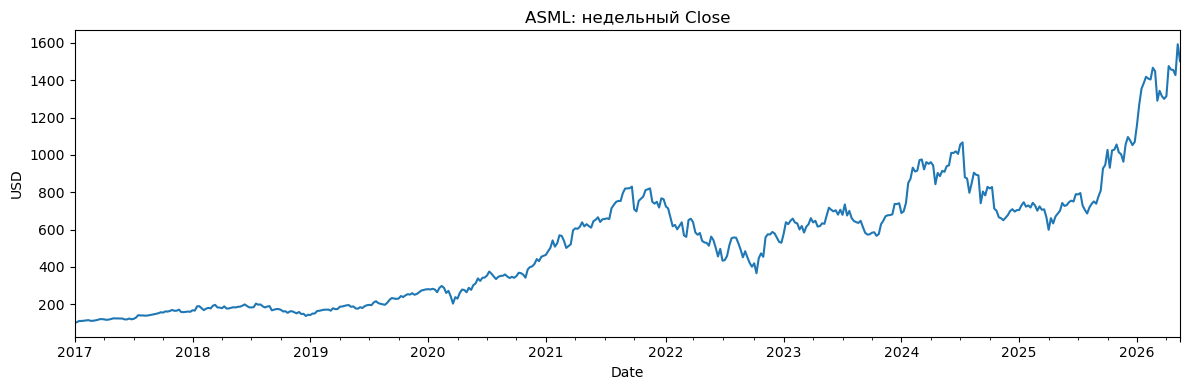

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.base import clone, BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor

%matplotlib inline

# --- данные и горизонты прогноза ---
START_DATE = '2017-01-01'  # с какой даты загружаем историю
TICKER = 'ASML'  # тикер акции
FORECAST_HORIZONS = [4, 13, 26, 52]  # прогноз на 4 / 13 / 26 / 52 недели вперёд
# подписи для таблиц и графиков
HORIZON_LABELS = {4: 'месяц (~4 нед.)', 13: 'квартал (~13 нед.)', 26: 'полгода (~26 нед.)', 52: 'год (~52 нед.)'}  

# --- train / test и кросс-валидация ---
N_SPLITS = 5  # число отрезков в TimeSeriesSplit
TEST_SIZE = 0.1  # доля ряда в отложенной test-выборке (последние 10%)

# --- признаки ---
LAG_RANGE = range(1, 53)  # лаги log-доходности: 1..52 недели назад
ROLL_WINDOWS = [4, 8, 13, 26, 52]  # окна для скользящих средних и std доходности
CAT_COLS = (  # признаки только для CatBoost (короче, чем у Ridge/Lasso)
    [f'ret_lag_{i}' for i in range(1, 9)]
    + [c for w in (4, 8, 13) for c in (f'ret_roll_mean_{w}', f'ret_roll_std_{w}')]
    + ['volatility', 'hl_range_pct']
)

# --- настройки моделей ---
NAIVE_WINDOW = 4  # сколько прошлых недель усредняет Naive-бейзлайн
RIDGE_ALPHAS = np.logspace(-2, 3, 30)  # сетка силы регуляризации Ridge
LASSO_ALPHAS = np.logspace(-8, -2.5, 100)  # сетка силы регуляризации Lasso

# --- графики и доверительные коридоры ---
CONFIDENCE_Z = 1.96  # ~95% коридор: среднее ± z * разброс
HIST_PLOT_WEEKS = 104  # длина истории на графике прогноза (~2 года)

tscv = TimeSeriesSplit(n_splits=N_SPLITS)  # CV без перемешивания, по времени
PREV_CLOSE = None  # цена прошлой недели; заполняется после load_weekly()


def mean_absolute_percentage_error(y_true, y_pred):
    """Средняя абсолютная ошибка в процентах от фактического значения."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def log_returns(close):
    """Недельная log-доходность: ln(цена_t / цена_{t-1})."""
    close = pd.Series(close, dtype=float)
    return np.log(close / close.shift(1))


def returns_to_close_series(index, pred_ret, prev_close_series):
    """Восстанавливает цену Close из предсказанной доходности и цены прошлой недели."""
    prev = prev_close_series.reindex(index).astype(float)
    pred = np.asarray(pred_ret, dtype=float)
    return pd.Series(prev.to_numpy() * np.exp(pred), index=index)


def add_return_features(log_ret, close, hl_range, lag_range=LAG_RANGE, roll_windows=ROLL_WINDOWS):
    """Строит признаки для модели: прошлые доходности, средние, волатильность, диапазон недели."""
    ret = pd.Series(log_ret, dtype=float)
    close = pd.Series(close, dtype=float)
    hl_range = pd.Series(hl_range, dtype=float)
    feats = pd.DataFrame(index=ret.index)
    for i in lag_range:
        feats[f'ret_lag_{i}'] = ret.shift(i)
    prev = ret.shift(1)
    for w in roll_windows:
        feats[f'ret_roll_mean_{w}'] = prev.rolling(w).mean()
        feats[f'ret_roll_std_{w}'] = prev.rolling(w).std()
    feats['volatility'] = prev.rolling(13).std()
    feats['hl_range_pct'] = hl_range / close
    return feats


def load_weekly(ticker=TICKER, start=START_DATE):
    """Скачивает дневные котировки и сводит их к недельным (пятница)."""
    df = yf.Ticker(ticker).history(start=start, auto_adjust=True)
    df.index = pd.to_datetime(df.index).tz_localize(None)
    weekly = df.resample('W-FRI').agg({
        'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum',
    }).dropna(subset=['Close'])
    weekly['hl_range'] = weekly['High'] - weekly['Low']
    weekly['log_ret'] = log_returns(weekly['Close'])
    return weekly


def build_dataset(weekly):
    """Таблица признаков X и целевая y — log-доходность Close на эту неделю."""
    feats = add_return_features(weekly['log_ret'], weekly['Close'], weekly['hl_range'])
    frame = feats.join(weekly['log_ret'].rename('y')).dropna()
    return frame.drop(columns=['y']), frame['y']


def timeseries_train_test_split(X, y, test_size=TEST_SIZE):
    """Делит ряд по времени: сначала train, в конце test; между ними буфер в одну неделю."""
    test_index = int(len(X) * (1 - test_size))
    return (
        X.iloc[: test_index - 1], X.iloc[test_index:],
        y.iloc[: test_index - 1], y.iloc[test_index:],
    )


weekly = load_weekly()
PREV_CLOSE = weekly['Close'].shift(1)
X, y = build_dataset(weekly)
X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y)
close_train = weekly.loc[X_train.index, 'Close']
close_test = weekly.loc[X_test.index, 'Close']

print(f'Недель: {len(weekly)}, наблюдений с признаками: {len(X)}')
print(f'Train: {len(X_train)}, test: {len(X_test)}')
print(f'Train: {X_train.index.min().date()} — {X_train.index.max().date()}')
print(f'Test:  {X_test.index.min().date()} — {X_test.index.max().date()}')

weekly['Close'].plot(figsize=(12, 4), title=f'{TICKER}: недельный Close')
plt.ylabel('USD')
plt.tight_layout()
plt.show()


---

## Часть 2. Модели, валидация и сравнение

In [2]:
from IPython.display import display, Markdown


class ReturnNaive(BaseEstimator, RegressorMixin):
    """Простой прогноз: средняя log-доходность за последние NAIVE_WINDOW недель."""

    def __init__(self, window=NAIVE_WINDOW):
        self.window = window
        self.lag_cols_ = None

    def fit(self, X, y=None):
        """Запоминает имена колонок с лагами доходности."""
        self.lag_cols_ = [f'ret_lag_{i}' for i in range(1, self.window + 1)]
        return self

    def predict(self, X):
        """Возвращает среднее по лагам доходности для каждой строки."""
        return X[self.lag_cols_].mean(axis=1).values


def make_catboost():
    """Создаёт настроенную модель CatBoost для регрессии доходности."""
    return CatBoostRegressor(
        iterations=80, depth=3, learning_rate=0.1, l2_leaf_reg=10,
        loss_function='MAE', random_seed=42, thread_count=1, verbose=0,
    )


MODEL_COLS = {'CatBoost': CAT_COLS}

PIPELINES = {
    'Naive': Pipeline([('model', ReturnNaive())]),
    'RidgeCV': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=RIDGE_ALPHAS, cv=tscv, scoring='neg_mean_absolute_error')),
    ]),
    'LassoCV': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LassoCV(alphas=LASSO_ALPHAS, cv=tscv, max_iter=30000, n_jobs=-1)),
    ]),
    'CatBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', make_catboost()),
    ]),
}


def features_for_model(name, X):
    """Возвращает нужные колонки X для выбранной модели."""
    cols = MODEL_COLS.get(name)
    return X if cols is None else X[cols]


def fit_model(name, X_tr, y_tr):
    """Обучает модель name на train-выборке."""
    pipe = clone(PIPELINES[name])
    pipe.fit(features_for_model(name, X_tr), y_tr)
    return pipe


def predict_returns(name, pipe, X_row):
    """Предсказывает log-доходность для одной недели (одна строка признаков)."""
    return float(pipe.predict(features_for_model(name, X_row))[0])


def predict_returns_batch(name, pipe, X):
    """Предсказывает log-доходность для нескольких недель сразу."""
    return pipe.predict(features_for_model(name, X))


def cv_one_step_scores(name, X, y):
    """Кросс-валидация на один шаг: средняя ошибка доходности и ошибки цены по каждому fold."""
    ret_errs, close_fold_maes = [], []
    for tr, va in tscv.split(X):
        fm = fit_model(name, X.iloc[tr], y.iloc[tr])
        pred_ret = predict_returns_batch(name, fm, X.iloc[va])
        ret_errs.extend(np.abs(y.iloc[va].values - pred_ret))
        pred_close = returns_to_close_series(X.index[va], pred_ret, PREV_CLOSE)
        close_fold_maes.append(mean_absolute_error(weekly.loc[X.index[va], 'Close'], pred_close))
    return float(np.mean(ret_errs)), close_fold_maes


def build_features_row_from_close(close_series, hl_last):
    """Считает признаки для последней недели по истории цен Close."""
    close = pd.Series(close_series, dtype=float)
    hl_range = pd.Series(hl_last, index=close.index, dtype=float)
    feats = add_return_features(log_returns(close), close, hl_range)
    return feats.iloc[[-1]].reindex(columns=X.columns)


def recursive_forecast_close(model_name, fitted_m, weekly_hist, horizon):
    """Прогноз цены Close на horizon недель вперёд, шаг за шагом."""
    hist = weekly_hist[['Close', 'hl_range']].copy()
    closes = []
    for _ in range(horizon):
        X_row = build_features_row_from_close(hist['Close'], hist['hl_range'].iloc[-1])
        if X_row.isna().any(axis=None):
            raise ValueError('Не хватает истории для признаков')
        r_hat = predict_returns(model_name, fitted_m, X_row)
        new_close = float(hist['Close'].iloc[-1] * np.exp(r_hat))
        new_idx = hist.index[-1] + pd.Timedelta(weeks=1)
        hist.loc[new_idx, ['Close', 'hl_range']] = [new_close, hist['hl_range'].iloc[-1]]
        closes.append(new_close)
    return pd.Series(closes, index=pd.DatetimeIndex(hist.index[-horizon:]))


def multi_step_cv_errors(model_name, X, y, weekly_df, max_horizon=max(FORECAST_HORIZONS)):
    """Ошибки рекурсивного прогноза цены в кросс-валидации по шагам и по горизонтам."""
    close = weekly_df['Close'].reindex(X.index)
    terminal_errors = {h: [] for h in FORECAST_HORIZONS}
    step_errors = {k: [] for k in range(1, max_horizon + 1)}
    for tr, _ in tscv.split(X):
        t0 = tr[-1]
        if t0 + max_horizon >= len(X):
            continue
        fm = fit_model(model_name, X.iloc[tr], y.iloc[tr])
        hist = weekly_df.loc[X.index[: t0 + 1], ['Close', 'hl_range']]
        path = recursive_forecast_close(model_name, fm, hist, max_horizon)
        for h in range(1, max_horizon + 1):
            err = float(close.iloc[t0 + h]) - float(path.iloc[h - 1])
            step_errors[h].append(err)
            if h in FORECAST_HORIZONS:
                terminal_errors[h].append(err)
    return terminal_errors, step_errors


fitted = {}
ms_cv_table = {}
ms_step_errors = {}
cv_close_band = {}
rows = []

for name in PIPELINES:
    fm = fit_model(name, X_train, y_train)
    fitted[name] = fm

    mae_cv_ret, close_folds = cv_one_step_scores(name, X_train, y_train)
    cv_close_band[name] = (np.mean(close_folds), np.std(close_folds))

    pred_ret = predict_returns_batch(name, fm, X_test)
    pred_close = returns_to_close_series(X_test.index, pred_ret, PREV_CLOSE)

    term_err, step_err = multi_step_cv_errors(name, X_train, y_train, weekly)
    ms_step_errors[name] = step_err
    ms_scores = {h: float(np.mean(np.abs(term_err[h]))) if term_err[h] else np.nan for h in FORECAST_HORIZONS}
    ms_cv_table[name] = ms_scores

    rows.append({
        'model': name,
        'MAE_CV_ret': mae_cv_ret,
        'MAE_test_ret': mean_absolute_error(y_test, pred_ret),
        'MAE_test_close': mean_absolute_error(close_test, pred_close),
        'MAPE_test_close': mean_absolute_percentage_error(close_test, pred_close),
        'MS_MAE_close': float(np.nanmean(list(ms_scores.values()))),
    })

results = pd.DataFrame(rows).set_index('model')
best_model = results['MS_MAE_close'].idxmin()

display(Markdown('#### MAE log-доходности — 1-step `TimeSeriesSplit(5)` на train'))
display(results[['MAE_CV_ret']].round(5))
display(Markdown(f'#### 1-step на hold-out ({int(TEST_SIZE * 100)}%)'))
display(results[['MAE_test_ret', 'MAE_test_close', 'MAPE_test_close']].round(4))
display(Markdown('#### Multi-step MAE Close (USD) — рекурсивный прогноз в CV'))
display(pd.DataFrame(ms_cv_table).T.round(2))
display(Markdown(f'**Лучшая модель (multi-step CV):** `{best_model}`'))


#### MAE log-доходности — 1-step `TimeSeriesSplit(5)` на train

,MAE_CV_ret
model,
Naive,0.04582
RidgeCV,0.04021
LassoCV,0.04176
CatBoost,0.04090


#### 1-step на hold-out (10%)

,MAE_test_ret,MAE_test_close,MAPE_test_close
model,,,
Naive,0.0491,56.1730,4.9217
RidgeCV,0.0437,48.6184,4.3144
LassoCV,0.0441,49.0110,4.3423
CatBoost,0.0443,49.6817,4.3020


#### Multi-step MAE Close (USD) — рекурсивный прогноз в CV

,4,13,26,52
Naive,97.15,140.70,198.42,481.48
RidgeCV,56.15,30.42,106.95,222.31
LassoCV,60.13,51.30,109.56,281.38
CatBoost,67.03,25.25,118.66,253.41


**Лучшая модель (multi-step CV):** `RidgeCV`

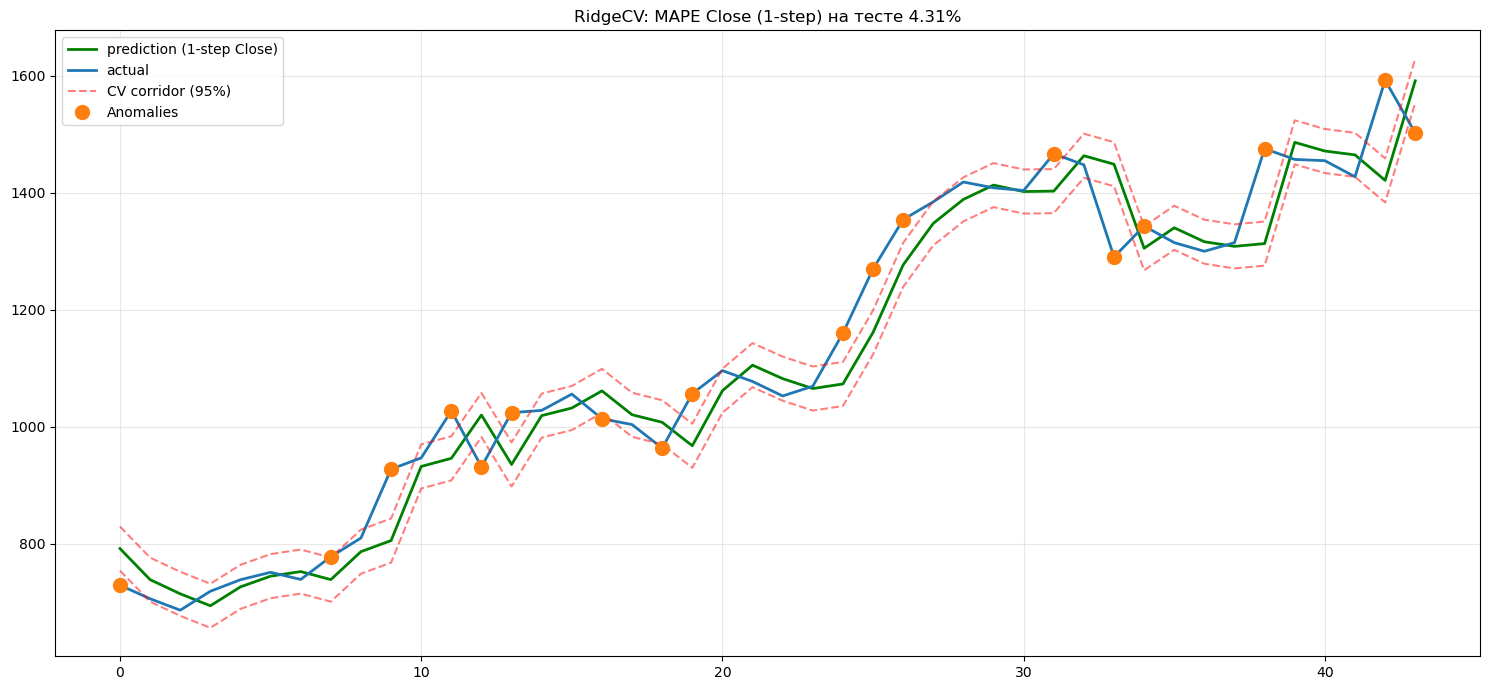

In [3]:
def one_step_close_predictions(model_name):
    """Предсказанная цена Close на каждой неделе отложенной test-выборки (один шаг)."""
    pred_ret = predict_returns_batch(model_name, fitted[model_name], X_test)
    return returns_to_close_series(X_test.index, pred_ret, PREV_CLOSE)


def plot_model_results(model_name, plot_intervals=True, plot_anomalies=False):
    """График: факт vs прогноз Close на test; опционально коридор и выбросы."""
    prediction = one_step_close_predictions(model_name)
    plt.figure(figsize=(15, 7))
    plt.plot(prediction.values, 'g', label='prediction (1-step Close)', linewidth=2)
    plt.plot(close_test.values, label='actual', linewidth=2)

    if plot_intervals:
        mae, std = cv_close_band[model_name]
        band = CONFIDENCE_Z * std + mae
        lower, upper = prediction.values - band, prediction.values + band
        plt.plot(lower, 'r--', label='CV corridor (95%)', alpha=0.5)
        plt.plot(upper, 'r--', alpha=0.5)
        if plot_anomalies:
            anomalies = np.full(len(close_test), np.nan)
            mask = (close_test.values < lower) | (close_test.values > upper)
            anomalies[mask] = close_test.values[mask]
            plt.plot(anomalies, 'o', markersize=10, label='Anomalies')

    mape = mean_absolute_percentage_error(close_test, prediction)
    plt.title(f'{model_name}: MAPE Close (1-step) на тесте {mape:.2f}%')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_model_results(best_model, plot_intervals=True, plot_anomalies=True)


---

## Часть 3. Прогноз за пределами выборки (4 / 13 / 26 / 52 нед.)

,h (нед.),горизонт,дата,прогноз Close,нижн. 95%,верхн. 95%,модель
0,4,месяц (~4 нед.),2026-06-12,1519.85,1394.41,1645.30,RidgeCV
1,13,квартал (~13 нед.),2026-08-14,1494.52,1425.81,1563.23,RidgeCV
2,26,полгода (~26 нед.),2026-11-13,1445.32,1205.39,1685.24,RidgeCV
3,52,год (~52 нед.),2027-05-14,1381.09,869.75,1892.43,RidgeCV


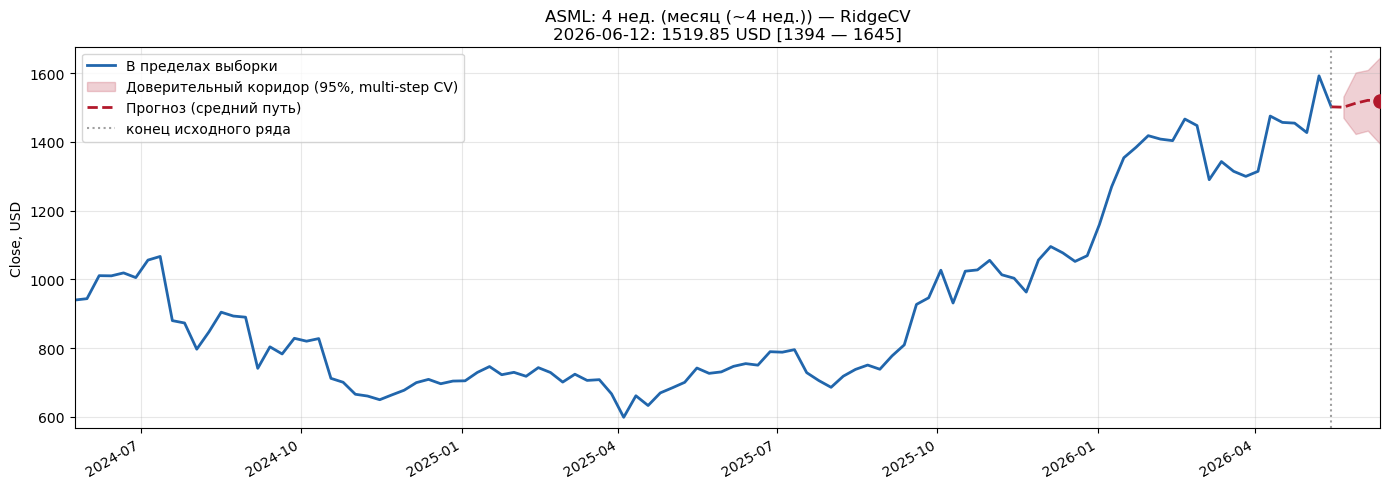

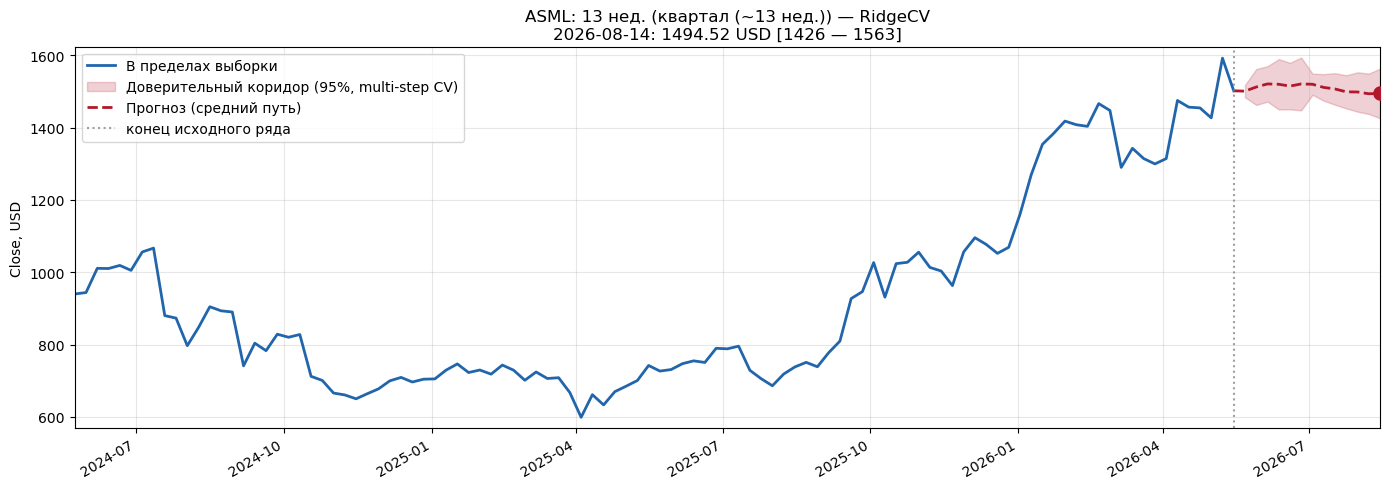

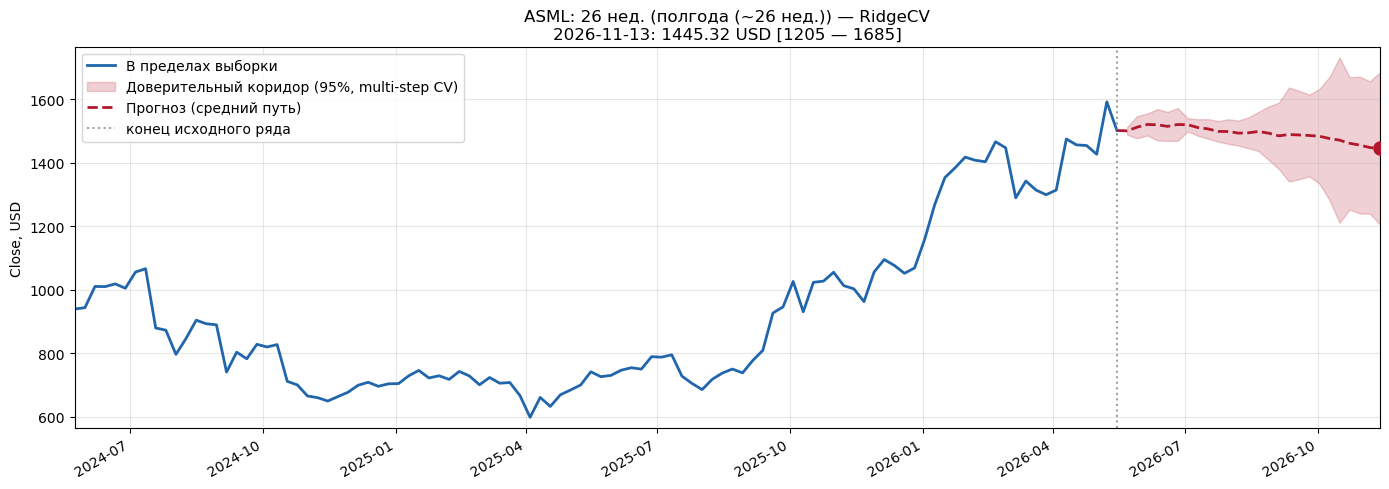

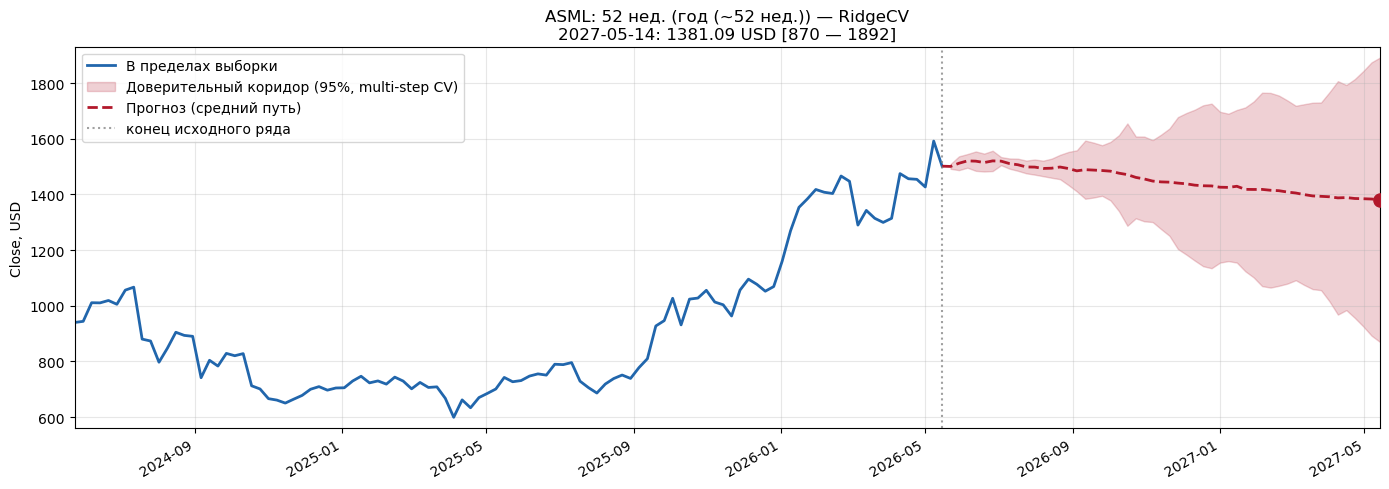

In [4]:
def forecast_path_with_bands(model_name, weekly_df, horizon):
    """Прогноз цены на horizon недель и доверительный коридор (нижняя/верхняя граница)."""
    hist = weekly_df[['Close', 'hl_range']].copy()
    mean_path = recursive_forecast_close(model_name, fitted[model_name], hist, horizon)
    step_err = ms_step_errors[model_name]
    k = np.arange(1, horizon + 1)
    std_k = np.array([float(np.std(step_err[i])) if step_err[i] else 0.0 for i in k])
    half_width = std_k * CONFIDENCE_Z * np.sqrt(k / horizon)
    return pd.DataFrame({
        'mean': mean_path,
        'lower': mean_path.to_numpy() - half_width,
        'upper': mean_path.to_numpy() + half_width,
    }, index=mean_path.index)


def plot_forecast_horizon(h, weekly_df, band, model_name):
    """Рисует историю цены и прогноз на h недель вперёд с коридором неопределённости."""
    close = weekly_df['Close']
    last_dt, last_val = close.index[-1], float(close.iloc[-1])
    forecast_path = band['mean']
    in_sample = close.iloc[-HIST_PLOT_WEEKS:]
    out_index = [last_dt, *forecast_path.index]
    out_values = [last_val, *forecast_path.to_numpy()]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(in_sample.index, in_sample.values, color='#2166ac', linewidth=2, label='В пределах выборки')
    ax.fill_between(forecast_path.index, band['lower'], band['upper'],
                    color='#b2182b', alpha=0.2, label='Доверительный коридор (95%, multi-step CV)')
    ax.plot(out_index, out_values, color='#b2182b', linewidth=2, linestyle='--', label='Прогноз (средний путь)')
    ax.scatter([forecast_path.index[-1]], [forecast_path.iloc[-1]], s=90, c='#b2182b', zorder=5)
    ax.axvline(last_dt, color='gray', linestyle=':', alpha=0.75, label='конец исходного ряда')

    y_all = np.concatenate([in_sample.to_numpy(), np.asarray(out_values),
                            band['lower'].to_numpy(), band['upper'].to_numpy()])
    pad = 0.03 * (y_all.max() - y_all.min() + 1e-6)
    ax.set_xlim(in_sample.index[0], out_index[-1])
    ax.set_ylim(y_all.min() - pad, y_all.max() + pad)
    ax.set_title(
        f'{TICKER}: {h} нед. ({HORIZON_LABELS[h]}) — {model_name}\n'
        f'{forecast_path.index[-1].date()}: {forecast_path.iloc[-1]:.2f} USD '
        f'[{band["lower"].iloc[-1]:.0f} — {band["upper"].iloc[-1]:.0f}]'
    )
    ax.set_ylabel('Close, USD')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


forecast_bands = {h: forecast_path_with_bands(best_model, weekly, h) for h in FORECAST_HORIZONS}
forecast_df = pd.DataFrame([
    {
        'h (нед.)': h, 'горизонт': HORIZON_LABELS[h], 'дата': band.index[-1],
        'прогноз Close': round(float(band['mean'].iloc[-1]), 2),
        'нижн. 95%': round(float(band['lower'].iloc[-1]), 2),
        'верхн. 95%': round(float(band['upper'].iloc[-1]), 2),
        'модель': best_model,
    }
    for h, band in forecast_bands.items()
])
display(forecast_df)
for h in FORECAST_HORIZONS:
    plot_forecast_horizon(h, weekly, forecast_bands[h], best_model)


### Выводы

- **Лучшая модель — RidgeCV** по среднему multi-step MAE Close в CV (~104 USD); Naive ~229, Lasso ~126, CatBoost ~139 USD (1-step на тесте CatBoost сопоставим, но на длинных горизонтах хуже в среднем).
- **Hold-out (1-step):** MAPE по Close ~**4,3%**, MAE ~**49 USD** у Ridge — заметно лучше Naive ( ~4,9% / ~56 USD).
- **Multi-step CV (Ridge):** ошибка растёт с горизонтом: ~56 USD (4 нед.) → ~30 (13) → ~107 (26) → ~222 (52); на год неопределённость существенно выше, чем на месяц.
- **Прогноз вперёд (Ridge):** от ~**1520 USD** (≈4 нед., июнь 2026) до ~**1381 USD** (≈52 нед., май 2027); коридоры расширяются — рекурсивная схема честно отражает накопление ошибки.
